In [1]:
import os
import requests
import pandas as pd
from urllib.parse import urljoin
from bs4 import BeautifulSoup
import sys
!{sys.executable} -m pip install mygene

In [2]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [3]:
os.chdir("/Users/ljw303/YANG_DATA/PrimeKG/datasets/data/disgenet/OpenTarget")

In [4]:
# ==== 1. Configuration ====
BASE_URL = "https://ftp.ebi.ac.uk/pub/databases/opentargets/platform/25.09/output/association_overall_direct/"
SAVE_DIR = "opentargets_associations"

os.makedirs(SAVE_DIR, exist_ok=True)

In [5]:
# ==== 2. List *.parquet files in GCS folder ====
def list_parquet_files(url):
    r = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")
    files = []

    for link in soup.find_all("a"):
        href = link.get("href")
        if href.endswith(".parquet"):
            files.append(urljoin(url, href))
    return files

files = list_parquet_files(BASE_URL)
print(f"Found {len(files)} files")

Found 20 files


In [6]:
# ==== 3. Download each file ====
def download_file(url, save_dir):
    name = url.split("/")[-1]
    path = os.path.join(save_dir, name)
    print(path)
    if not os.path.exists(path):
        print("Downloading:", name)
        r = requests.get(url)
        with open(path, "wb") as f:
            f.write(r.content)
    else:
        print("Already exists:", name)

    return path

# local_files = [download_file(f, SAVE_DIR) for f in files]

In [7]:
# local_files

In [8]:
ls /Users/ljw303/YANG_DATA/PrimeKG/datasets/data/disgenet/OpenTarget/opentargets_associations

part-00000-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00001-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00002-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00003-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00004-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00005-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00006-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00007-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00008-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00009-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00010-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00011-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00012-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00013-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet
part-00014-115d4937-47d3-4de3-a70b-eb4fc9f78010-

In [9]:
local_files = os.listdir("/Users/ljw303/YANG_DATA/PrimeKG/datasets/data/disgenet/OpenTarget/opentargets_associations")
local_files

['part-00011-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00006-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00016-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00001-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00017-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00000-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00010-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00007-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00009-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00015-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00002-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00012-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00019-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00005-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.pa

In [10]:
path = "/Users/ljw303/YANG_DATA/PrimeKG/datasets/data/disgenet/OpenTarget/opentargets_associations"

In [11]:
ls

20251120-ProcessOpenTargetData.ipynb
20251121-EnsemblID-Genename.csv
20260212-OpenTarget_disease_protein_associations.csv
20260417-EnsemblID-Genename.csv
Homo_sapiens.GRCh38.115.gtf
Homo_sapiens.GRCh38.115.gtf.gz
Homo_sapiens.GRCh38.115.no.header.gtf
OpenTargets_associations_merged.csv
OpenTargets_associations_merged.parquet
disease.parquet
homo.sapien.txt
opentargets_associations/
score_distribution_all0.1.png
score_distribution_all0.3.png
score_distribution_non_overlapping0.1.png
score_distribution_non_overlapping0.3.png
score_distribution_overlapping0.1.png
score_distribution_overlapping0.3.png


In [12]:
# ==== 4. Read and merge all parquet files ====
# dfs = [pd.read_parquet(path + "/"+ f) for f in local_files]
# full_df = pd.concat(dfs, ignore_index=True)

# print("Final dataset shape:", full_df.shape)

# # Save to one file
# full_df.to_csv("OpenTargets_associations_merged.csv")

full_df = pd.read_csv("OpenTargets_associations_merged.csv")


In [13]:
full_df.head(3)

,Unnamed: 0,diseaseId,targetId,score,evidenceCount
0,0,HP_0001518,ENSG00000006071,0.266097,1
1,1,HP_0001518,ENSG00000054983,0.332622,2
2,2,HP_0001518,ENSG00000068078,0.340013,1


In [14]:
full_df.evidenceCount.describe()

count    3.987332e+06
mean     7.603350e+00
std      1.373098e+02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      5.134600e+04
Name: evidenceCount, dtype: float64

In [15]:
full_df.score.min(), full_df.score.max()

(np.float64(0.0007902492030084), np.float64(0.9133450071938024))

In [16]:
len(full_df), len(full_df.diseaseId.unique())

(3987332, 22778)

In [17]:
full_df.head(3)

,Unnamed: 0,diseaseId,targetId,score,evidenceCount
0,0,HP_0001518,ENSG00000006071,0.266097,1
1,1,HP_0001518,ENSG00000054983,0.332622,2
2,2,HP_0001518,ENSG00000068078,0.340013,1


In [18]:
opentargetThreshold = 0.1
full_df = full_df[full_df.score>=opentargetThreshold] #change here for difference comparison between score =0.1 and 0.3

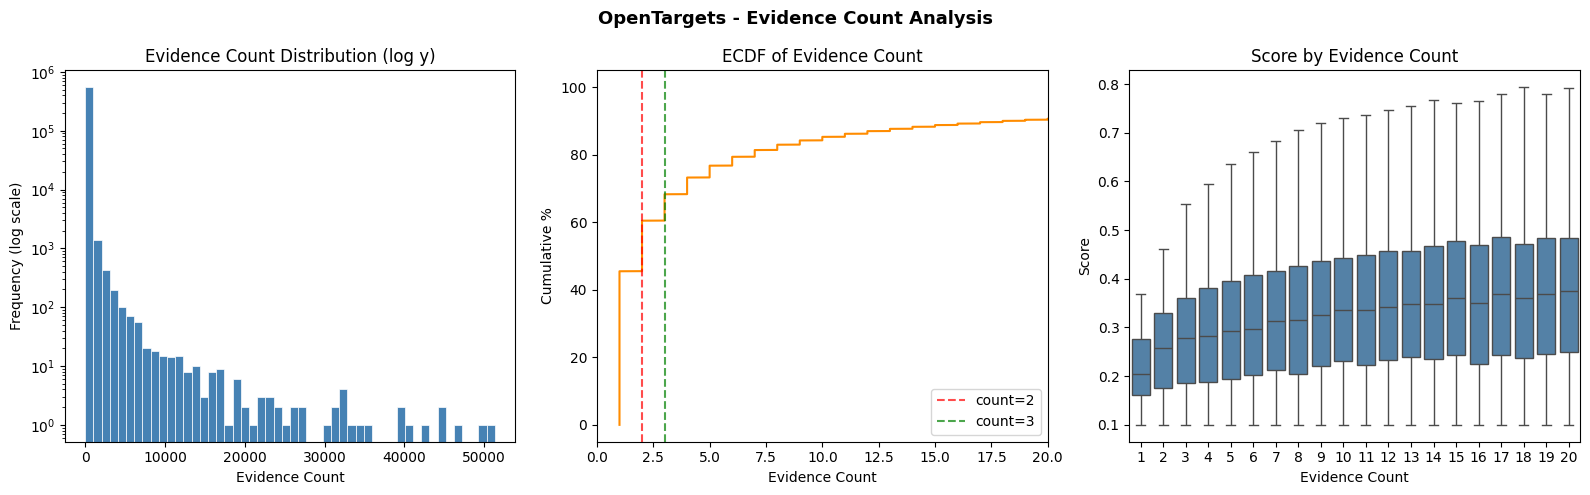

count    551397.000000
mean         28.138722
std         364.317697
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max       51346.000000
Name: evidenceCount, dtype: float64

Proportion with count=1:  45.5%
Proportion with count>=2: 54.5%
Proportion with count>=3: 39.5%


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histogram (log-scale y-axis to show long tail)
axes[0].hist(full_df['evidenceCount'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_yscale('log')
axes[0].set_xlabel('Evidence Count')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Evidence Count Distribution (log y)')

# 2. ECDF — cumulative % for threshold choice
sorted_counts = np.sort(full_df['evidenceCount'])
ecdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
axes[1].plot(sorted_counts, ecdf * 100, color='darkorange')
axes[1].axvline(x=2, color='red', linestyle='--', alpha=0.7, label='count=2')
axes[1].axvline(x=3, color='green', linestyle='--', alpha=0.7, label='count=3')
axes[1].set_xlabel('Evidence Count')
axes[1].set_ylabel('Cumulative %')
axes[1].set_title('ECDF of Evidence Count')
axes[1].legend()
axes[1].set_xlim(0, 20)  # zoom to head

# 3. Fix: use seaborn boxplot instead of pandas boxplot
import seaborn as sns
count_cap = min(full_df['evidenceCount'].quantile(0.95), 20)
df_plot = full_df[full_df['evidenceCount'] <= count_cap].copy()
df_plot['evidenceCount'] = df_plot['evidenceCount'].astype(int)

sns.boxplot(data=df_plot, x='evidenceCount', y='score', ax=axes[2], color='steelblue')
axes[2].set_xlabel('Evidence Count')
axes[2].set_ylabel('Score')
axes[2].set_title('Score by Evidence Count')

plt.suptitle('OpenTargets - Evidence Count Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print(full_df['evidenceCount'].describe())
print(f"\nProportion with count=1:  {(full_df['evidenceCount']==1).mean():.1%}")
print(f"Proportion with count>=2: {(full_df['evidenceCount']>=2).mean():.1%}")
print(f"Proportion with count>=3: {(full_df['evidenceCount']>=3).mean():.1%}")

In [20]:
full_df_bkup = full_df
full_df = full_df[full_df.score>=0.1]

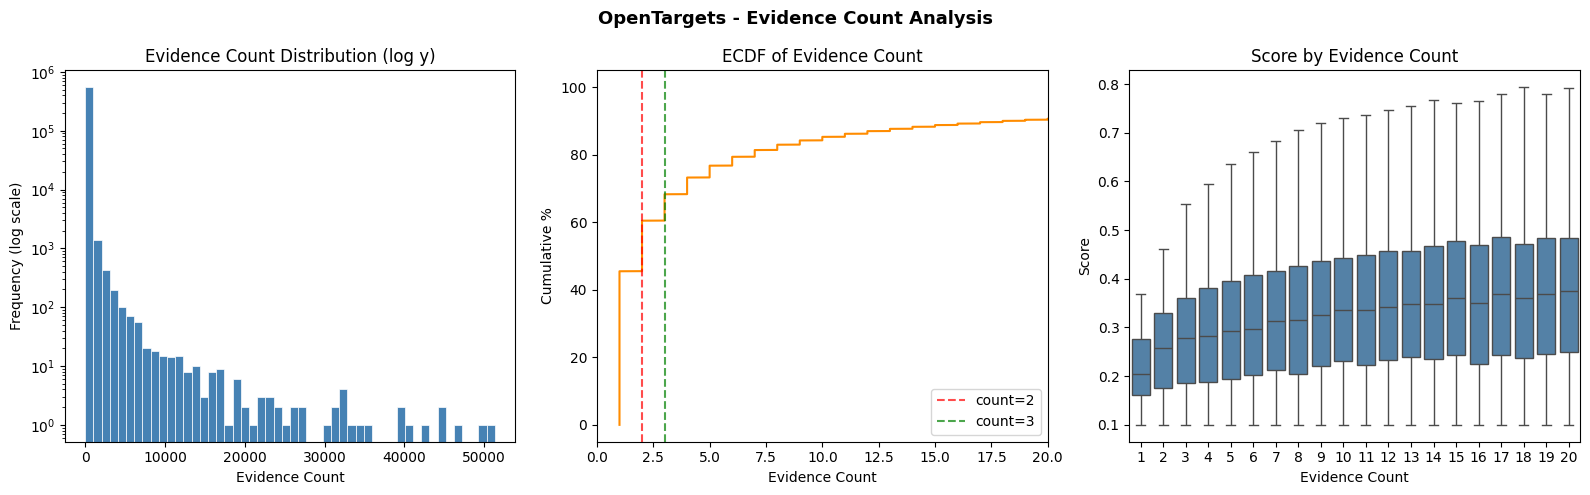

count    551397.000000
mean         28.138722
std         364.317697
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max       51346.000000
Name: evidenceCount, dtype: float64

Proportion with count=1:  45.5%
Proportion with count>=2: 54.5%
Proportion with count>=3: 39.5%


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histogram (log-scale y-axis to show long tail)
axes[0].hist(full_df['evidenceCount'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_yscale('log')
axes[0].set_xlabel('Evidence Count')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Evidence Count Distribution (log y)')

# 2. ECDF — cumulative % for threshold choice
sorted_counts = np.sort(full_df['evidenceCount'])
ecdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
axes[1].plot(sorted_counts, ecdf * 100, color='darkorange')
axes[1].axvline(x=2, color='red', linestyle='--', alpha=0.7, label='count=2')
axes[1].axvline(x=3, color='green', linestyle='--', alpha=0.7, label='count=3')
axes[1].set_xlabel('Evidence Count')
axes[1].set_ylabel('Cumulative %')
axes[1].set_title('ECDF of Evidence Count')
axes[1].legend()
axes[1].set_xlim(0, 20)  # zoom to head

# 3. Fix: use seaborn boxplot instead of pandas boxplot
import seaborn as sns
count_cap = min(full_df['evidenceCount'].quantile(0.95), 20)
df_plot = full_df[full_df['evidenceCount'] <= count_cap].copy()
df_plot['evidenceCount'] = df_plot['evidenceCount'].astype(int)

sns.boxplot(data=df_plot, x='evidenceCount', y='score', ax=axes[2], color='steelblue')
axes[2].set_xlabel('Evidence Count')
axes[2].set_ylabel('Score')
axes[2].set_title('Score by Evidence Count')

plt.suptitle('OpenTargets - Evidence Count Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print(full_df['evidenceCount'].describe())
print(f"\nProportion with count=1:  {(full_df['evidenceCount']==1).mean():.1%}")
print(f"Proportion with count>=2: {(full_df['evidenceCount']>=2).mean():.1%}")
print(f"Proportion with count>=3: {(full_df['evidenceCount']>=3).mean():.1%}")

In [22]:
full_df['evidenceCount'].max()

np.int64(51346)

In [23]:
len(full_df), len(full_df.diseaseId.unique())

(551397, 18475)

In [24]:
disease_df = pd.read_parquet("/Users/ljw303/YANG_DATA/PrimeKG/datasets/data/disgenet/OpenTarget/disease.parquet")
len(disease_df)

39530

In [25]:
disease_df.head(4)

,id,code,name,description,dbXRefs,parents,synonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology
0,DOID_0050890,http://purl.obolibrary.org/obo/DOID_0050890,synucleinopathy,A neurodegenerative disease that is characteri...,"[UMLS:C5191670, MONDO:0000510, MEDGEN:1682194,...","[MONDO_0019052, MONDO_0021179, MONDO_0024237]",{'hasExactSynonym': ['alpha Synucleinopathies'...,[],[],"[EFO_0006792, EFO_1001050]","[MONDO_0019052, MONDO_0021179, EFO_0009386, MO...","[OTAR_0000020, EFO_0000618, OTAR_0000018]","[MONDO_0000211, MONDO_0016418, MONDO_0014835, ...","{'isTherapeuticArea': False, 'leaf': False, 's..."
1,DOID_10113,http://purl.obolibrary.org/obo/DOID_10113,trypanosomiasis,Infection with protozoa of the genus trypanosoma.,"[MONDO:0000940, NANDO:2200774, ICD10CM:B56, DO...",[MONDO_0002428],{'hasExactSynonym': ['Trypanosoma caused disea...,[],[],"[MONDO_0001444, EFO_0005225, EFO_0008559]","[EFO_0001067, EFO_0005741, MONDO_0002428]",[EFO_0005741],"[MONDO_0001444, EFO_0005225, EFO_0008559, EFO_...","{'isTherapeuticArea': False, 'leaf': False, 's..."
2,DOID_10718,http://purl.obolibrary.org/obo/DOID_10718,giardiasis,An infection of the small intestine caused by ...,"[MEDGEN:42213, SCTID:10679007, DOID:10718, icd...","[MONDO_0002428, EFO_0009561]","{'hasExactSynonym': ['beaver fever', 'giardias...",[],[],[],"[EFO_0009431, EFO_0001067, MONDO_0043424, EFO_...","[EFO_0010282, EFO_0005741]",[],"{'isTherapeuticArea': False, 'leaf': False, 's..."
3,DOID_13406,http://purl.obolibrary.org/obo/DOID_13406,pulmonary sarcoidosis,Sarcoidosis affecting the lung parenchyma. It ...,"[MONDO:0001708, MESH:D017565, SNOMEDCT:2436900...","[MONDO_0017026, MONDO_0019338]","{'hasExactSynonym': ['pulmonary sarcoidosis', ...",[],[],[EFO_1001232],"[MONDO_0019751, EFO_1001986, EFO_0004244, EFO_...","[OTAR_0000006, OTAR_0000010]",[EFO_1001232],"{'isTherapeuticArea': False, 'leaf': False, 's..."


In [26]:
# !tail -n +6  Homo_sapiens.GRCh38.115.gtf > Homo_sapiens.GRCh38.115.no.header.gtf

In [27]:
# !head -n5 Homo_sapiens.GRCh38.115.no.header.gtf

In [28]:
# gtf = pd.read_csv("Homo_sapiens.GRCh38.115.no.header.gtf", sep="\t", header=None)
# gtf.columns = ["col0", "col1", "col2", "col3", "col4", "col5", "col6", "col7", "col8"]
# gtf.head(3)

In [29]:
# gtf = gtf[(gtf.col2=="gene")&(gtf.col8.str.contains("gene_name "))]
# len(gtf)

In [30]:
# gtf.head()

In [31]:
# with open("homo.sapien.txt", "w") as f:
#     for value in gtf["col8"]:
#         pairs = value.split(";")
#         for pair in pairs:
#             f.write(str(value) + "\n")

In [32]:
# !head -n10 homo.sapien.txt # we still take genes with gene_biotype "processed_pseudogene" as this is just for annotation

In [33]:
# temp = []
# with open("homo.sapien.txt", "r") as f:
#     lines = f.readlines()
#     for line in lines:
#         pairs = line[:-1].split("; ")
#         t = []
#         for pair in pairs:
#             t.append(pair.split(" ")[1][1:-1])
#         t[-1]= t[-1][:-1]
#         temp.append(t)
# geneAnnotation = pd.DataFrame(temp, columns=["gene_id","gene_version","gene_name","gene_source","gene_biotype"])
# geneAnnotation = geneAnnotation[geneAnnotation.gene_biotype == "protein_coding"]
# geneAnnotation = geneAnnotation.drop_duplicates(subset=["gene_id", "gene_name"])
# geneAnnotation

In [34]:
print(len(full_df), len(full_df.targetId.unique()))
full_df.head(2)

551397 19075


,Unnamed: 0,diseaseId,targetId,score,evidenceCount
0,0,HP_0001518,ENSG00000006071,0.266097,1
1,1,HP_0001518,ENSG00000054983,0.332622,2


In [35]:
unique_targets = full_df['targetId'].dropna().astype(str).unique().tolist()
# remove any non-ENSG (if your ids include ENSP etc.)
ensgs = [t for t in unique_targets if t.startswith("ENSG")]
len(ensgs)

19075

In [36]:
#time consuming -run once
dict = {}
for i, ensg in enumerate(ensgs):
    url = f"https://rest.ensembl.org/lookup/id/{ensg}?content-type=application/json"
    try:
        r = requests.get(url, headers={"Content-Type":"application/json"})
        r.raise_for_status()
        js = r.json()
        symbol = js.get("display_name")
        dict[ensg] = symbol
    except Exception as e:
        # Fallback: store None or "NA" and print warning
        dict[ensg] = None
        print(f"Warning: failed to fetch {ensg} — {e}")
    if (i)%100==0:
        print("progressing at i = ",i)

progressing at i =  0
progressing at i =  100
progressing at i =  200
progressing at i =  300
progressing at i =  400
progressing at i =  500
progressing at i =  600
progressing at i =  700
progressing at i =  800
progressing at i =  900
progressing at i =  1000
progressing at i =  1100
progressing at i =  1200
progressing at i =  1300
progressing at i =  1400
progressing at i =  1500
progressing at i =  1600
progressing at i =  1700
progressing at i =  1800
progressing at i =  1900
progressing at i =  2000
progressing at i =  2100
progressing at i =  2200
progressing at i =  2300
progressing at i =  2400
progressing at i =  2500
progressing at i =  2600
progressing at i =  2700
progressing at i =  2800
progressing at i =  2900
progressing at i =  3000
progressing at i =  3100
progressing at i =  3200
progressing at i =  3300
progressing at i =  3400
progressing at i =  3500
progressing at i =  3600
progressing at i =  3700
progressing at i =  3800
progressing at i =  3900
progressing 

In [37]:
len(dict.keys())

19075

In [38]:
with open("20260417-EnsemblID-Genename.csv", "w") as f:
    for key in dict.keys():
        v = dict.get(key)
        # print(v, " ", type(v))
        if v!=None:
            f.write(key+","+v+"\n")

In [39]:
temp = pd.read_csv("20260417-EnsemblID-Genename.csv", header=None)
temp.columns = ["EnsemblID", "Genename"]
print(len(temp))
temp.head(3)

18959


,EnsemblID,Genename
0,ENSG00000006071,ABCC8
1,ENSG00000054983,GALC
2,ENSG00000068078,FGFR3


In [40]:
full_df.head(2)

,Unnamed: 0,diseaseId,targetId,score,evidenceCount
0,0,HP_0001518,ENSG00000006071,0.266097,1
1,1,HP_0001518,ENSG00000054983,0.332622,2


In [41]:
disease_df.head(2)

,id,code,name,description,dbXRefs,parents,synonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology
0,DOID_0050890,http://purl.obolibrary.org/obo/DOID_0050890,synucleinopathy,A neurodegenerative disease that is characteri...,"[UMLS:C5191670, MONDO:0000510, MEDGEN:1682194,...","[MONDO_0019052, MONDO_0021179, MONDO_0024237]",{'hasExactSynonym': ['alpha Synucleinopathies'...,[],[],"[EFO_0006792, EFO_1001050]","[MONDO_0019052, MONDO_0021179, EFO_0009386, MO...","[OTAR_0000020, EFO_0000618, OTAR_0000018]","[MONDO_0000211, MONDO_0016418, MONDO_0014835, ...","{'isTherapeuticArea': False, 'leaf': False, 's..."
1,DOID_10113,http://purl.obolibrary.org/obo/DOID_10113,trypanosomiasis,Infection with protozoa of the genus trypanosoma.,"[MONDO:0000940, NANDO:2200774, ICD10CM:B56, DO...",[MONDO_0002428],{'hasExactSynonym': ['Trypanosoma caused disea...,[],[],"[MONDO_0001444, EFO_0005225, EFO_0008559]","[EFO_0001067, EFO_0005741, MONDO_0002428]",[EFO_0005741],"[MONDO_0001444, EFO_0005225, EFO_0008559, EFO_...","{'isTherapeuticArea': False, 'leaf': False, 's..."


In [42]:
rs = pd.merge(full_df, temp, left_on="targetId", right_on="EnsemblID", how="inner")
rs.head(2)

,Unnamed: 0,diseaseId,targetId,score,evidenceCount,EnsemblID,Genename
0,0,HP_0001518,ENSG00000006071,0.266097,1,ENSG00000006071,ABCC8
1,1,HP_0001518,ENSG00000054983,0.332622,2,ENSG00000054983,GALC


In [43]:
rs = pd.merge(rs, disease_df, left_on="diseaseId", right_on="id", how="inner")
rs.head(2)

,Unnamed: 0,diseaseId,targetId,score,evidenceCount,EnsemblID,Genename,id,code,name,...,dbXRefs,parents,synonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology
0,0,HP_0001518,ENSG00000006071,0.266097,1,ENSG00000006071,ABCC8,HP_0001518,http://purl.obolibrary.org/obo/HP_0001518,Small for gestational age,...,"[SNOMEDCT_US:276610007, UMLS:C0235991, UMLS:C0...",[HP_0004325],{'hasExactSynonym': ['Birth weight less than 1...,[],[],[],"[EFO_0000651, HP_0004323, HP_0004325, HP_00015...",[EFO_0000651],[],"{'isTherapeuticArea': False, 'leaf': False, 's..."
1,1,HP_0001518,ENSG00000054983,0.332622,2,ENSG00000054983,GALC,HP_0001518,http://purl.obolibrary.org/obo/HP_0001518,Small for gestational age,...,"[SNOMEDCT_US:276610007, UMLS:C0235991, UMLS:C0...",[HP_0004325],{'hasExactSynonym': ['Birth weight less than 1...,[],[],[],"[EFO_0000651, HP_0004323, HP_0004325, HP_00015...",[EFO_0000651],[],"{'isTherapeuticArea': False, 'leaf': False, 's..."


In [44]:
rs.columns

Index(['Unnamed: 0', 'diseaseId', 'targetId', 'score', 'evidenceCount',
       'EnsemblID', 'Genename', 'id', 'code', 'name', 'description', 'dbXRefs',
       'parents', 'synonyms', 'obsoleteTerms', 'obsoleteXRefs', 'children',
       'ancestors', 'therapeuticAreas', 'descendants', 'ontology'],
      dtype='object')

In [45]:
len(rs)

550158

In [46]:
rs = rs[["Genename", "score", "EnsemblID", "name","dbXRefs"]]
rs.head(2)

,Genename,score,EnsemblID,name,dbXRefs
0,ABCC8,0.266097,ENSG00000006071,Small for gestational age,"[SNOMEDCT_US:276610007, UMLS:C0235991, UMLS:C0..."
1,GALC,0.332622,ENSG00000054983,Small for gestational age,"[SNOMEDCT_US:276610007, UMLS:C0235991, UMLS:C0..."


In [47]:
import pandas as pd
import numpy as np
import ast

def parse_pairs(cell):

    # 1️⃣ Actual NaN
    if cell is None:
        return {}

    # 2️⃣ numpy array
    if isinstance(cell, np.ndarray):
        cell = cell.tolist()

    # 3️⃣ Actual list
    if isinstance(cell, list):
        items = cell

    # 4️⃣ string
    elif isinstance(cell, str):
        cell = cell.strip()

        # empty string
        if cell == "":
            return {}

        # string representation of a list
        if cell.startswith("[") and cell.endswith("]"):
            try:
                items = ast.literal_eval(cell)
            except:
                return {}
        else:
            # string like MONDO:..., NANDO:...
            items = [x.strip() for x in cell.split(",")]

    else:
        return {}

    # 5️⃣ Parse each item
    result = {}
    for item in items:
        if isinstance(item, str) and ":" in item:
            name, value = item.split(":", 1)
            result[name.strip()] = value.strip()

    return result


parsed_series = rs["dbXRefs"].apply(parse_pairs)

# all_names = set()
# for d in parsed_series:
#     all_names.update(d.keys())

# print("All names:", all_names)

expanded_df = pd.DataFrame(parsed_series.tolist())

df_final = pd.concat([rs.drop(columns=["dbXRefs"]), expanded_df], axis=1)


In [48]:
df_final.head(3)

,Genename,score,EnsemblID,name,SNOMEDCT_US,UMLS,Fyler,MEDDRA,ICD10,MESH,...,NPO,Medgen,ICD11,PubChem,CAS,SNOMED,MPATH,doi,PR,chebi
0,ABCC8,0.266097,ENSG00000006071,Small for gestational age,267258002,C0024032,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GALC,0.332622,ENSG00000054983,Small for gestational age,267258002,C0024032,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FGFR3,0.340013,ENSG00000068078,Small for gestational age,267258002,C0024032,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
len(df_final)

550158

In [50]:
df_final.columns

Index(['Genename', 'score', 'EnsemblID', 'name', 'SNOMEDCT_US', 'UMLS',
       'Fyler', 'MEDDRA', 'ICD10', 'MESH', 'SNOMEDCT', 'ICD-10', 'ICD9',
       'DOID', 'OMIM', 'NCIt', 'EPCC', 'MedDRA', 'NCIT', 'HP', 'MP', 'PMID',
       'MEDGEN', 'OMIMPS', 'GARD', 'Orphanet', 'NANDO', 'SCTID',
       'icd11.foundation', 'ICD10CM', 'NORD', 'EFO', 'MONDO', 'CSP', 'ICDO',
       'ONCOTREE', 'SCTID_2010_1_31', 'Wikipedia', 'COHD', 'uniprot', 'IDO',
       'ICD9CM', 'GTR', 'UniProt', 'ICD10EXP', 'ORDO', 'HGNC', 'SCDO',
       'ICD10WHO', 'NIFSTD', 'DECIPHER', 'KEGG',
       'CRISP Thesaurus 2006, Term Number 2000-0386, http', 'Reactome', 'GO',
       'https', 'MedlinePlus', 'OAE', 'CMO', 'modelled on http', 'http',
       'ISBN-10', 'ISBN-13', 'MO', 'PERSON', 'MFOMD', 'DC', 'OBI', 'MTH',
       'NCIm', 'snomedct', 'KEGG COMPOUND', 'HMDB', 'MedGen', 'SYMP', 'DI',
       'ORCID', 'OMIT', 'ENM', 'TXPO', 'NPO', 'Medgen', 'ICD11', 'PubChem',
       'CAS', 'SNOMED', 'MPATH', 'doi', 'PR', 'chebi'],
      

In [51]:
df_final = df_final[['Genename', 'score', 'EnsemblID', 'name', 'UMLS']]

In [52]:
df_final.head(5)

,Genename,score,EnsemblID,name,UMLS
0,ABCC8,0.266097,ENSG00000006071,Small for gestational age,C0024032
1,GALC,0.332622,ENSG00000054983,Small for gestational age,C0024032
2,FGFR3,0.340013,ENSG00000068078,Small for gestational age,C0024032
3,PTGS2,0.258706,ENSG00000073756,Small for gestational age,C0024032
4,PTGS1,0.258706,ENSG00000095303,Small for gestational age,C0024032


In [53]:
df_final = df_final.drop_duplicates()
len(df_final)

550155

In [54]:
df_final = df_final.dropna()
len(df_final)

276297

In [55]:
len(df_final.name.unique())

10464

In [56]:
len(df_final.EnsemblID.unique())

17621

In [57]:
data_path = "/Users/ljw303/YANG_DATA/PrimeKG/datasets/data/"

In [58]:
df_disgenet = pd.read_csv(data_path+'disgenet/Authors-curated_gene_disease_associations.tsv', sep='\t', low_memory=False)
df_disgenet = df_disgenet.astype({'geneId':int}).astype({'geneId':str})
print("len df_disgenet:", len(df_disgenet))
# print("columns df_disgenet:", df_disgenet.columns)
df_disgenet.head(3)

len df_disgenet: 84038


,geneId,geneSymbol,DSI,DPI,diseaseId,diseaseName,diseaseType,diseaseClass,diseaseSemanticType,score,EI,YearInitial,YearFinal,NofPmids,NofSnps,source
0,1,A1BG,0.700,0.538,C0019209,Hepatomegaly,phenotype,C23;C06,Finding,0.3,1.000,2017.0,2017.0,1,0,CTD_human
1,1,A1BG,0.700,0.538,C0036341,Schizophrenia,disease,F03,Mental or Behavioral Dysfunction,0.3,1.000,2015.0,2015.0,1,0,CTD_human
2,2,A2M,0.529,0.769,C0002395,Alzheimer's Disease,disease,C10;F03,Disease or Syndrome,0.5,0.769,1998.0,2018.0,3,0,CTD_human


In [59]:
df_disgenet.diseaseName.unique()[:5]

array(['Hepatomegaly', 'Schizophrenia', "Alzheimer's Disease",
       'Malignant tumor of colon', 'Colonic Neoplasms'], dtype=object)

In [60]:
df_disgenet.diseaseName = df_disgenet.diseaseName.str.lower()

In [61]:
df_disgenet.head(2)

,geneId,geneSymbol,DSI,DPI,diseaseId,diseaseName,diseaseType,diseaseClass,diseaseSemanticType,score,EI,YearInitial,YearFinal,NofPmids,NofSnps,source
0,1,A1BG,0.7,0.538,C0019209,hepatomegaly,phenotype,C23;C06,Finding,0.3,1.0,2017.0,2017.0,1,0,CTD_human
1,1,A1BG,0.7,0.538,C0036341,schizophrenia,disease,F03,Mental or Behavioral Dysfunction,0.3,1.0,2015.0,2015.0,1,0,CTD_human


In [62]:
df_final.head(2)

,Genename,score,EnsemblID,name,UMLS
0,ABCC8,0.266097,ENSG00000006071,Small for gestational age,C0024032
1,GALC,0.332622,ENSG00000054983,Small for gestational age,C0024032


In [63]:
#now calculate the overalap between df_disgenet (score >=0.3) and disgenet (df_final, no score threshold)
df_disgenet_simple = df_disgenet[["geneSymbol", "diseaseId", "score"]]
opentarget_simple = df_final[["Genename", "UMLS", "score"]]
opentarget_simple.columns = ["geneSymbol", "diseaseId", "score"]

In [64]:
print(len(opentarget_simple))
print(len(opentarget_simple[opentarget_simple.score>=0.3]))
print(len(df_disgenet_simple[df_disgenet_simple.score>=0.3]))

276297
78853
84038


In [65]:
78853/3114073

0.02532150017035567

In [66]:
opentarget_simple.score.describe()

count    276297.000000
mean          0.264114
std           0.131852
min           0.100003
25%           0.184790
50%           0.258706
75%           0.323382
max           0.913345
Name: score, dtype: float64

In [67]:
df_disgenet_simple.score.describe()

count    84038.000000
mean         0.357034
std          0.123150
min          0.300000
25%          0.300000
50%          0.300000
75%          0.340000
max          1.000000
Name: score, dtype: float64

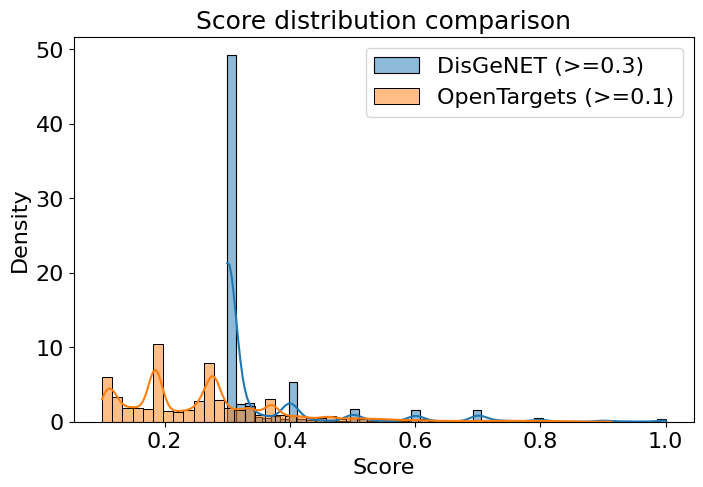

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
})

plt.figure(figsize=(8,5))

sns.histplot(df_disgenet_simple["score"], 
             label=f"DisGeNET (>=0.3)", 
             kde=True, 
             stat="density", 
             bins=50)

sns.histplot(opentarget_simple["score"], 
             label=f"OpenTargets (>={opentargetThreshold})", 
             kde=True, 
             stat="density", 
             bins=50)

plt.legend()
plt.xlabel("Score")
plt.title("Score distribution comparison")
plt.show()

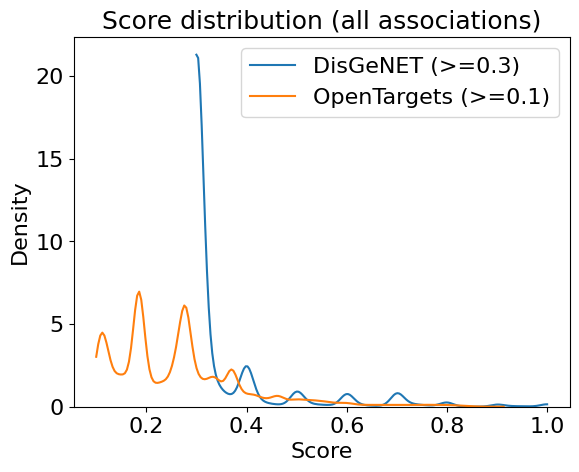

In [69]:
# plt.figure(figsize=(8,5))

sns.kdeplot(df_disgenet_simple["score"], label="DisGeNET (>=0.3)", cut=0)
sns.kdeplot(opentarget_simple["score"], label=f"OpenTargets (>={opentargetThreshold})", cut=0)

plt.legend()
plt.xlabel("Score")
plt.title("Score distribution (all associations)")
# Save
plt.savefig(f"score_distribution_all{opentargetThreshold}.png", dpi=300, bbox_inches='tight')
plt.show()

In [70]:
df_overlap = df_disgenet_simple.merge(
    opentarget_simple,
    on=["geneSymbol", "diseaseId"],
    suffixes=("_disgenet", "_opentarget")
)
print(len(df_overlap))
df_overlap.head()

14528


,geneSymbol,diseaseId,score_disgenet,score_opentarget
0,NAT2,C0005684,0.40,0.449081
1,NAT2,C0006142,0.40,0.229925
2,NAT2,C0860207,0.40,0.318120
3,NAT2,C1956346,0.31,0.480631
4,AARS1,C2750090,0.71,0.740389


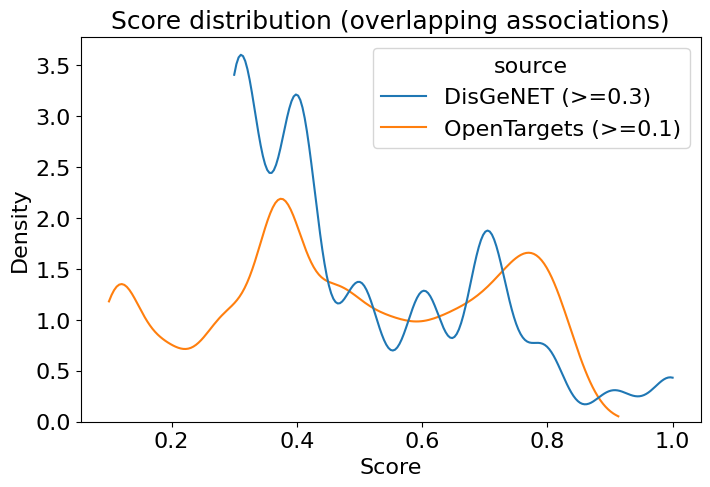

In [71]:
df_plot = pd.concat([
    df_overlap[["score_disgenet"]].rename(columns={"score_disgenet": "score"})
        .assign(source="DisGeNET (>=0.3)"),
    df_overlap[["score_opentarget"]].rename(columns={"score_opentarget": "score"})
        .assign(source=f"OpenTargets (>={opentargetThreshold})")
])

plt.figure(figsize=(8,5))

sns.kdeplot(data=df_plot, x="score", hue="source", common_norm=False, cut=0)

plt.title("Score distribution (overlapping associations)")
plt.xlabel("Score")
# Save
plt.savefig(f"score_distribution_overlapping{opentargetThreshold}.png", dpi=300, bbox_inches='tight')
plt.show()

In [72]:
df_overlap

,geneSymbol,diseaseId,score_disgenet,score_opentarget
0,NAT2,C0005684,0.40,0.449081
1,NAT2,C0006142,0.40,0.229925
2,NAT2,C0860207,0.40,0.318120
3,NAT2,C1956346,0.31,0.480631
4,AARS1,C2750090,0.71,0.740389
...,...,...,...,...
14523,OCLN,C2931662,0.32,0.756058
14524,OCLN,C3489725,0.62,0.643993
14525,MICA,C2239176,0.40,0.116423
14526,NOTCH2NLC,C1863843,0.53,0.499981


In [73]:
from scipy.stats import gaussian_kde

kde1 = gaussian_kde(df_overlap["score_disgenet"])
kde2 = gaussian_kde(df_overlap["score_opentarget"])

x = np.linspace(-0.5, 1.5, 2000)

print(np.trapz(kde1(x), x))  # ~1
print(np.trapz(kde2(x), x))  # ~1

0.9999999999999989
0.9999999999999968


/var/folders/rh/fl3hq65n6_dbw6bssnkh01r80000gn/T/ipykernel_18167/3706568999.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(np.trapz(kde1(x), x))  # ~1
/var/folders/rh/fl3hq65n6_dbw6bssnkh01r80000gn/T/ipykernel_18167/3706568999.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(np.trapz(kde2(x), x))  # ~1


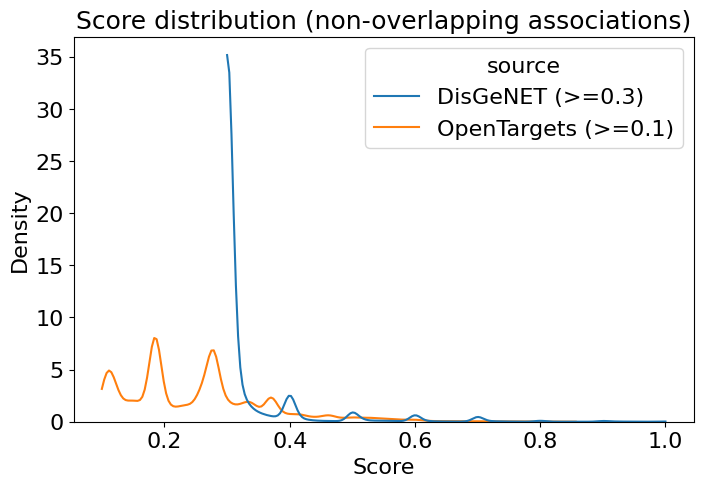

In [74]:


# --- Step 1: find overlapping pairs ---
df_overlap = df_disgenet_simple.merge(
    opentarget_simple,
    on=["geneSymbol", "diseaseId"],
    how="inner"
)

# --- Step 2: find non-overlapping pairs ---
df_disgenet_non = df_disgenet_simple.merge(
    df_overlap[["geneSymbol", "diseaseId"]],
    on=["geneSymbol", "diseaseId"],
    how="left",
    indicator=True
).query('_merge == "left_only"').drop(columns="_merge")

df_opentarget_non = opentarget_simple.merge(
    df_overlap[["geneSymbol", "diseaseId"]],
    on=["geneSymbol", "diseaseId"],
    how="left",
    indicator=True
).query('_merge == "left_only"').drop(columns="_merge")

# --- Step 3: reshape to long format ---
df_plot = pd.concat([
    df_disgenet_non[["score"]].assign(source="DisGeNET (>=0.3)"),
    df_opentarget_non[["score"]].assign(source=f"OpenTargets (>={opentargetThreshold})")
])

# --- Step 4: plot ---
plt.figure(figsize=(8,5))

sns.kdeplot(data=df_plot, x="score", hue="source", common_norm=False, cut=0)

plt.xlabel("Score")
plt.title("Score distribution (non-overlapping associations)")

# Save
plt.savefig(f"score_distribution_non_overlapping{opentargetThreshold}.png", dpi=300, bbox_inches='tight')
plt.show()

In [75]:
import mygene
import pandas as pd

mg = mygene.MyGeneInfo()

genes = df_final.Genename.unique()

result = mg.querymany(
    genes,
    scopes="symbol",
    fields="entrezgene",
    species="human"
)

df_ids = pd.DataFrame(result)
print(df_ids[["query", "entrezgene"]])


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
99 input query terms found dup hits:	[('GUCY1B2', 2), ('IGHE', 2), ('HBD', 2), ('IGHG1', 2), ('FCGR2C', 2), ('ORAI1', 2), ('CAST', 2), ('
59 input query terms found no hit:	['GTDC1', 'FAM210A', 'C12orf50', 'MFSD4A', 'FUT10', 'MFSD9', 'NEPRO', 'CIR1', 'CCDC65', 'NDUFA4', 'F


         query entrezgene
0        ABCC8       6833
1         GALC       2581
2        FGFR3       2261
3        PTGS2       5743
4        PTGS1       5742
...        ...        ...
17689  MAB21L4      79919
17690  ZC2HC1B     153918
17691  EIF5AL1     143244
17692  B4GALT4       8702
17693     CTRL       1506

[17694 rows x 2 columns]


In [76]:
df_ids = df_ids[['query', 'entrezgene']]

In [77]:
df_ids.columns = ["Genename", "NCBI_ID"]

In [78]:
df_disgenet_disease = df_disgenet.diseaseName.unique()
df_final_disease = df_final.name.unique()
len([x for x in df_final_disease if not x in df_disgenet_disease])

8952

In [79]:
df_disgenet_gene = df_disgenet.geneSymbol.unique()
df_final_gene = df_final.Genename.unique()
len([x for x in df_final_gene if not x in df_disgenet_gene])

8736

In [80]:
df_disgenet["pairs"] = df_disgenet["geneSymbol"] + "_" + df_disgenet["diseaseName"]
df_final["pairs"] = df_final["Genename"] + "_" + df_final["name"]
df_final.head(3)

,Genename,score,EnsemblID,name,UMLS,pairs
0,ABCC8,0.266097,ENSG00000006071,Small for gestational age,C0024032,ABCC8_Small for gestational age
1,GALC,0.332622,ENSG00000054983,Small for gestational age,C0024032,GALC_Small for gestational age
2,FGFR3,0.340013,ENSG00000068078,Small for gestational age,C0024032,FGFR3_Small for gestational age


In [81]:
df_disgenet_pairs = df_disgenet.pairs.unique()
df_final_pairs = df_final.pairs.unique()
new_pairs = [p for p in df_final_pairs if not p in df_disgenet_pairs]
rows_for_adding = df_final[df_final.pairs.isin(new_pairs)]
len(rows_for_adding), len(df_final)

(271368, 276297)

In [82]:
new_pairs

['ABCC8_Small for gestational age',
 'GALC_Small for gestational age',
 'FGFR3_Small for gestational age',
 'PTGS2_Small for gestational age',
 'PTGS1_Small for gestational age',
 'SMARCAL1_Small for gestational age',
 'FGF5_Small for gestational age',
 'AUH_Small for gestational age',
 'ASXL1_Small for gestational age',
 'DHCR7_Small for gestational age',
 'INF2_Small for gestational age',
 'RPL17_Small for gestational age',
 'MYLK_Disproportionate tall stature',
 'TGFBR1_Disproportionate tall stature',
 'DLG4_Disproportionate tall stature',
 'SKI_Disproportionate tall stature',
 'PDZD8_Disproportionate tall stature',
 'FBN1_Disproportionate tall stature',
 'COL3A1_Disproportionate tall stature',
 'PTCH1_Disproportionate tall stature',
 'SLC2A10_Disproportionate tall stature',
 'COL5A2_Disproportionate tall stature',
 'ABCC8_Large for gestational age',
 'ATP6V0A1_Large for gestational age',
 'WAPL_Large for gestational age',
 'DNMT3A_Large for gestational age',
 'PTEN_Large for gestat

In [83]:
rows_for_adding.head(3)

,Genename,score,EnsemblID,name,UMLS,pairs
0,ABCC8,0.266097,ENSG00000006071,Small for gestational age,C0024032,ABCC8_Small for gestational age
1,GALC,0.332622,ENSG00000054983,Small for gestational age,C0024032,GALC_Small for gestational age
2,FGFR3,0.340013,ENSG00000068078,Small for gestational age,C0024032,FGFR3_Small for gestational age


In [84]:
df_ids.head(3)

,Genename,NCBI_ID
0,ABCC8,6833
1,GALC,2581
2,FGFR3,2261


In [85]:
final_rs = pd.merge(rows_for_adding, df_ids, left_on="Genename", right_on="Genename", how="inner")

In [86]:
final_rs.head(3)

,Genename,score,EnsemblID,name,UMLS,pairs,NCBI_ID
0,ABCC8,0.266097,ENSG00000006071,Small for gestational age,C0024032,ABCC8_Small for gestational age,6833
1,GALC,0.332622,ENSG00000054983,Small for gestational age,C0024032,GALC_Small for gestational age,2581
2,FGFR3,0.340013,ENSG00000068078,Small for gestational age,C0024032,FGFR3_Small for gestational age,2261


In [87]:
final_rs.columns

Index(['Genename', 'score', 'EnsemblID', 'name', 'UMLS', 'pairs', 'NCBI_ID'], dtype='object')

In [88]:
# geneId → renamed to x_id (gene/protein ID)
# geneSymbol → renamed to x_name (gene/protein name)
# diseaseId → merge with df_umls_mondo (not in final kg.csv)
# diseaseType → used to filter:

final_rs.columns = ['x_name', 'score', 'EnsemblID', 'diseaseName', 'diseaseId', 'pairs', "x_id"]

In [89]:
final_rs.head(10)

,x_name,score,EnsemblID,diseaseName,diseaseId,pairs,x_id
0,ABCC8,0.266097,ENSG00000006071,Small for gestational age,C0024032,ABCC8_Small for gestational age,6833
1,GALC,0.332622,ENSG00000054983,Small for gestational age,C0024032,GALC_Small for gestational age,2581
2,FGFR3,0.340013,ENSG00000068078,Small for gestational age,C0024032,FGFR3_Small for gestational age,2261
3,PTGS2,0.258706,ENSG00000073756,Small for gestational age,C0024032,PTGS2_Small for gestational age,5743
4,PTGS1,0.258706,ENSG00000095303,Small for gestational age,C0024032,PTGS1_Small for gestational age,5742
5,SMARCAL1,0.425017,ENSG00000138375,Small for gestational age,C0024032,SMARCAL1_Small for gestational age,50485
6,FGF5,0.359483,ENSG00000138675,Small for gestational age,C0024032,FGF5_Small for gestational age,2250
7,AUH,0.169961,ENSG00000148090,Small for gestational age,C0024032,AUH_Small for gestational age,549
8,ASXL1,0.340013,ENSG00000171456,Small for gestational age,C0024032,ASXL1_Small for gestational age,171023
9,DHCR7,0.406538,ENSG00000172893,Small for gestational age,C0024032,DHCR7_Small for gestational age,1717


In [90]:
final_rs.to_csv("20260426-OpenTarget_disease_protein_associations.csv")

In [91]:
!pwd

/Users/ljw303/YANG_DATA/PrimeKG/datasets/data/disgenet/OpenTarget
